In [2]:
include(joinpath(@__DIR__, "..", "Helper_util", "util.jl"))
include(joinpath(@__DIR__, "..", "Parameter", "parameter.jl"));

In [3]:
## Define the diffusion coefficients and wave WaveNumber
diffusion_coefficient = DiffusionParameter(1, 0.0001, 0.001, 0.0001)


total_population=Total_Population(1.45).total

λ, ν = global_parameter_1.λ, global_parameter_1.ν
d₁, d₂ = diffusion_coefficient.d₁, diffusion_coefficient.d₂
k=3;

## ODE_PDE_eigen

In [4]:
function lhs_term(λ, ν)
    return N -> (ν/λ)*N / (N + 1)
end
function rhs_term(N_t, m)
    return N -> (N_t - N)^(m-1)
end;



function visulize_equilibrium_state_2D(N_t,λ,ν,m)
    lhs = lhs_term(λ, ν)
    rhs = rhs_term(N_t, m)

    # Generate range of N values
    N_vals = range(0, N_t-0.01, length=500)

    # Evaluate functions
    lhs_vals = lhs.(N_vals)
    rhs_vals = rhs.(N_vals)

    # Find intersection numerically
    f_diff = N -> lhs(N) - rhs(N)

    root = find_zero(f_diff, (0, 0.01), verbose=false)
    println("Root is $root, with m being $m")

    
    # Plot
    plot(N_vals, lhs_vals, label = "LHS", lw=2, xlims=(0, 0.05),ylims=(0, 10),title = "m = $m, root ≈ $root")
    plot!(N_vals, rhs_vals, label = "RHS", lw=2, linestyle=:dash)
    return root
end



function equilibrium_state_2D(N_t,λ,ν,m)
    ## record the length of vector N_t
    num_pt=length(N_t)
    # Pre-define the vector P_star and N_star as vector to store the equilibrium values for each N_t[i]
    P̄,N̄=zeros(Float64,num_pt),zeros(Float64,num_pt)

    # running the for loop for every N_t
    for i in 1:num_pt
       N̄[i]= visulize_equilibrium_state_2D(N_t[i],λ,ν,m)
       P̄[i]=N_t[i]-N̄[i]

       ## if there is no such real roots in the restricted range [0,N_t[i]], we use -1 to denote N and P
       if 0 <= N̄[i] && N̄[i] <= N_t[i] && 0 <= P̄[i] && P̄[i] <= N_t[i]
           continue
       else
           N̄[i]= -1
           P̄[i]= -1
       end
   end
   
   return(N̄,P̄)
end


function ODE_PDE_system_2D(Nₜ,λ,ν,m,d₁,d₂,k)

    N̄,P̄=equilibrium_state_2D(Nₜ,λ,ν,m)
    result=[]
    for i in 1:length(Nₜ)
        Nᵢ,Pᵢ=N̄[i],P̄[i]
        if Nᵢ == -1 && Pᵢ==-1
           key=[-0.1,-0.1, Nₜ[i]]
        else
           ## Define the Jacobian matrix at equilibrium states
           A=zeros(2,2)
           A=[-ν*Pᵢ/((1+Nᵢ)^2)   (m-1)*λ*Pᵢ^(m-1)
               ν*Pᵢ/((1+Nᵢ)^2)   -(m-1)*λ*Pᵢ^(m-1)]
           ## define the linear approximation matrix for PDE system
           diffusion_vec=[d₁,d₂]
           diffusion_mat=diagm(0 => -(k^2)*diffusion_vec)
           pde_mat=A+diffusion_mat
           ode_mat=A
           eigen_pde=eigen(pde_mat).values
           ## define the maximum of real part of eigenvalue
           key_eigen_pde = maximum(real(eigen_pde))
           max_index= argmax(real(eigen_pde))

           eigen_ode=eigen(ode_mat).values
           key_eigen_ode = maximum(real(eigen_ode))
           ## define the eigenvector corresponding to the largest eigenvalue
           eigen_vec=(eigen(pde_mat).vectors)[:,max_index]
           
           key=[key_eigen_ode,key_eigen_pde,Nₜ[i],eigen_vec]
           
        end
        push!(result,key)
    end
    return(result)
end


function plot_pde_eigenvalues_2D(Nₜ, λ, ν, m, d₁, d₂, k_range, xlim_range, ylim_range)
    eigen_pde_values = []
    
    for k in k_range
        result = ODE_PDE_system_2D(Nₜ, λ, ν, m, d₁, d₂,k)[1]
        push!(eigen_pde_values, result[2])
    end

    # Plot max real part of PDE eigenvalue vs k
    p = plot(
        k_range,
        eigen_pde_values,
        xlabel = "k",
        ylabel = "Max Re(λ)",
        lw = 2,
        label = "Max Re(λ)",
        ylim = ylim_range,
        xlim = xlim_range,
        title = "m = $m"
    )
    hline!([0], linestyle=:dash, color=:black, label="")
end



    

plot_pde_eigenvalues_2D (generic function with 1 method)

## Visualization of Equilibrium points N

Root is 0.0021878213771662426, with m being 0.25
Root is 0.002195959452602458, with m being 0.26
Root is 0.002204127651218675, with m being 0.27
Root is 0.0022123260829419694, with m being 0.28
Root is 0.0022205548580853003, with m being 0.29
Root is 0.0022288140873487207, with m being 0.3
Root is 0.002237103881820596, with m being 0.31
Root is 0.002245424352978822, with m being 0.32
Root is 0.0022537756126920438, with m being 0.33
Root is 0.0022621577732208783, with m being 0.34
Root is 0.002270570947219145, with m being 0.35
Root is 0.0022790152477350895, with m being 0.36
Root is 0.0022874907882126164, with m being 0.37
Root is 0.0022959976824925192, with m being 0.38
Root is 0.002304536044813722, with m being 0.39
Root is 0.0023131059898145114, with m being 0.4
Root is 0.002321707632533781, with m being 0.41
Root is 0.002330341088412274, with m being 0.42
Root is 0.0023390064732938236, with m being 0.43
Root is 0.0023477039034266096, with m being 0.44
Root is 0.0023564334954644006,

┌ Info: Saved animation to C:\Users\xiang\AppData\Local\Temp\jl_vorcPcRCZk.gif
└ @ Plots C:\Users\xiang\.julia\packages\Plots\3u4B6\src\animation.jl:156


Plots.AnimatedGif("C:\\Users\\xiang\\AppData\\Local\\Temp\\jl_vorcPcRCZk.gif")
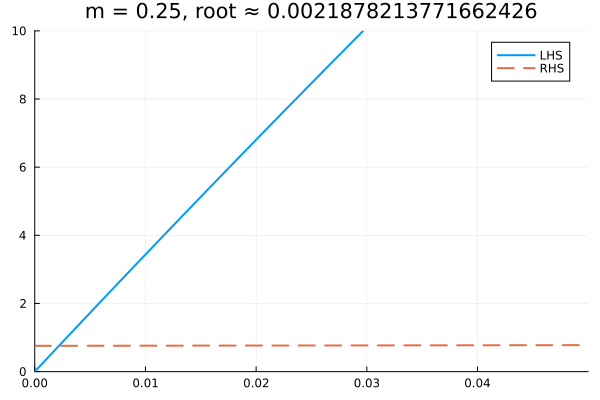

In [46]:
@gif for m in 0.25:0.01:1.0
    visulize_equilibrium_state_2D(1.45, λ, ν, m)
end every 2  # Controls frame delay (higher = slower playback)

Root is 0.002001265364505273, with m being 0.01
Root is 0.002001265364505273, with m being 0.01
Root is 0.002001265364505273, with m being 0.01
Root is 0.002001265364505273, with m being 0.01
Root is 0.002001265364505273, with m being 0.01
Root is 0.002001265364505273, with m being 0.01
Root is 0.002001265364505273, with m being 0.01
Root is 0.002001265364505273, with m being 0.01
Root is 0.002001265364505273, with m being 0.01
Root is 0.002001265364505273, with m being 0.01
Root is 0.002001265364505273, with m being 0.01
Root is 0.002001265364505273, with m being 0.01
Root is 0.002001265364505273, with m being 0.01
Root is 0.002001265364505273, with m being 0.01
Root is 0.002001265364505273, with m being 0.01
Root is 0.002001265364505273, with m being 0.01
Root is 0.002001265364505273, with m being 0.01
Root is 0.002001265364505273, with m being 0.01
Root is 0.002001265364505273, with m being 0.01
Root is 0.002001265364505273, with m being 0.01
Root is 0.002001265364505273, with m bei

┌ Info: Saved animation to C:\Users\xiang\AppData\Local\Temp\jl_XCvIPkxQJs.gif
└ @ Plots C:\Users\xiang\.julia\packages\Plots\3u4B6\src\animation.jl:156


Plots.AnimatedGif("C:\\Users\\xiang\\AppData\\Local\\Temp\\jl_XCvIPkxQJs.gif")
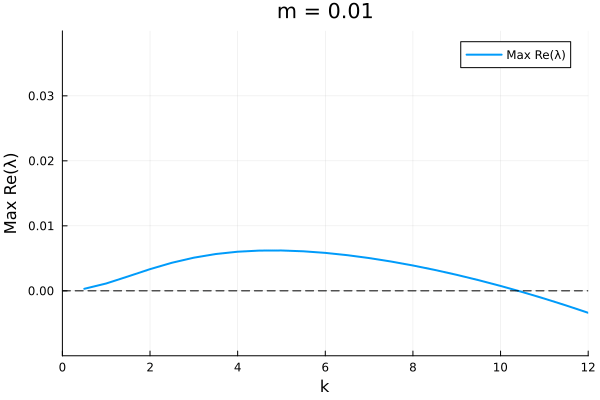

In [85]:
k_range = 0.5:0.5:12
# Animate over m
@gif for m in 0.01:0.01:1.0
    plot_pde_eigenvalues_2D([1.45], λ, ν, m, d₁, d₂, k_range, (0, 12), (-0.01, 0.04))
end every 2  # Use 'every' to slow down or speed up frame rate

## NPZ model with ODE_PDE_eigen

In [1]:
include(joinpath(@__DIR__, "..", "Helper_util", "util.jl"))
include(joinpath(@__DIR__, "..", "Parameter", "parameter.jl"));

In [2]:
## Define the diffusion coefficients and wave WaveNumber
diffusion_coefficient = DiffusionParameter(5, 0.001, 0.001, 0.001)


total_population=Total_Population(0.4).total


## parameter setting up 2
Nₜ = global_parameter_1.Nₜ
λ, ν = global_parameter_1.λ, global_parameter_1.ν
δ, g, m = global_parameter_1.δ, global_parameter_1.g, global_parameter_1.m
d₁, d₂, d₃, d₄, k = diffusion_coefficient.d₁, diffusion_coefficient.d₂, diffusion_coefficient.d₃, diffusion_coefficient.d₄, WaveNumber(2).k;
d₁_vec=Diffusion_Vec_Parameter(0.1:0.1:10).d_vec;

In [26]:
function plot_pde_eigenvalues_3D(N_t, λ, ν, δ, g, m, d₁, d₂, d₃, k_range, xlim_range, ylim_range)
    eigen_pde_values = []
    
    for k in k_range
        result = ODE_PDE_system_3D(N_t, λ, ν, δ, g, m, d₁, d₂, d₃, k)[1][2]
        push!(eigen_pde_values, result)
    end

    # Plot max real part of PDE eigenvalue vs k
    p = plot(
        k_range,
        eigen_pde_values,
        xlabel = "k",
        ylabel = "Max Re(λ)",
        lw = 2,
        label = "Max Re(λ)",
        ylim = ylim_range,
        xlim = xlim_range,
        title = "m = $m"
    )
    hline!([0], linestyle=:dash, color=:black, label="")
end

plot_pde_eigenvalues_3D (generic function with 2 methods)

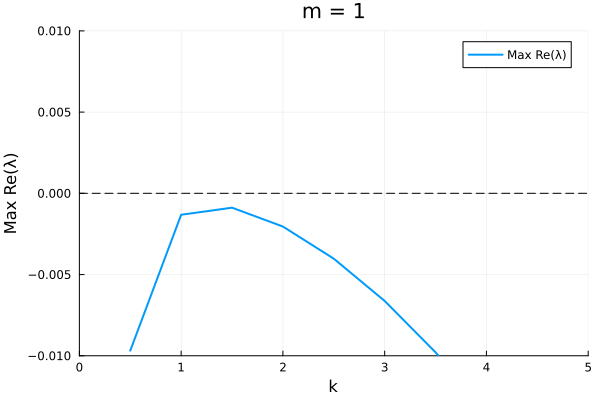

In [4]:
m=1
k_range = 0.5:0.5:5
plot_pde_eigenvalues_3D(total_population, λ, ν, δ, g, m, d₁, d₂, d₃, k_range, (0, 5), (-0.01, 0.01))

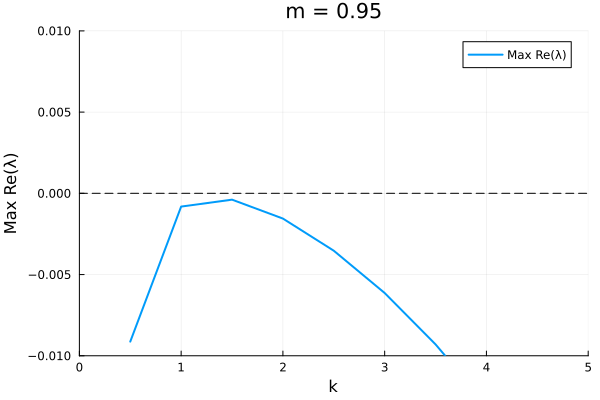

In [50]:
m=0.95
k_range = 0.5:0.5:5
plot_pde_eigenvalues_3D(total_population, λ, ν, δ, g, m, d₁, d₂, d₃, k_range, (0, 5), (-0.01, 0.01))

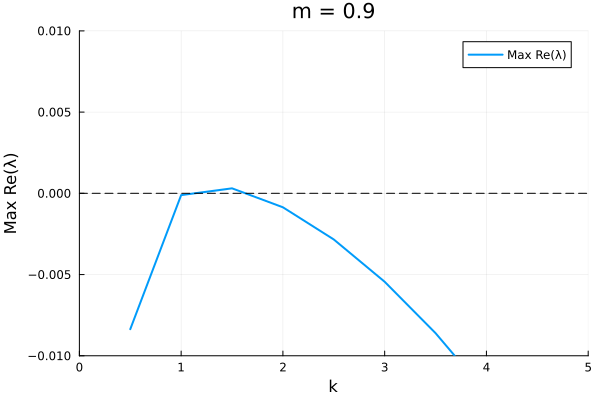

In [51]:
m=0.9
k_range = 0.5:0.5:5
plot_pde_eigenvalues_3D(total_population, λ, ν, δ, g, m, d₁, d₂, d₃, k_range, (0, 5), (-0.01, 0.01))

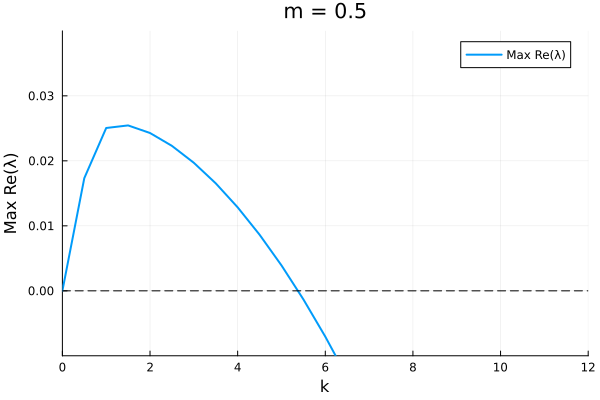

In [7]:
m=0.5
k_range = 0:0.5:12
plot_pde_eigenvalues_3D(total_population, λ, ν, δ, g, m, d₁, d₂, d₃, k_range, (0, 12), (-0.01, 0.04))

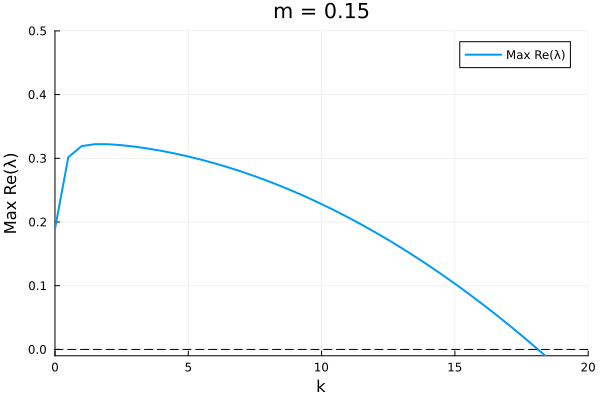

In [8]:
m=0.15
k_range = 0:0.5:20
plot_pde_eigenvalues_3D(total_population, λ, ν, δ, g, m, d₁, d₂, d₃, k_range, (0, 20), (-0.01, 0.5))

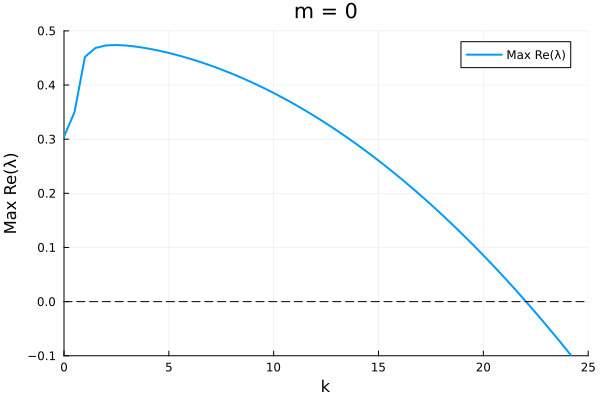

In [32]:
m=0
k_range = 0:0.5:25
plot_pde_eigenvalues_3D(total_population, λ, ν, δ, g, m, d₁, d₂, d₃, k_range, (0, 25), (-0.1,0.5))

## Heatmap of PDE eigen v.s. m and k

In [37]:
function plot_eigenvalue_heatmap_3D(Nₜ, λ, ν, δ, g, m, d₁, d₂, d₃, m_range, k_range)
    heatmap_data = zeros(length(m_range), length(k_range))

    for (i, m) in enumerate(m_range)
        for (j, k) in enumerate(k_range)
            result = ODE_PDE_system_3D(Nₜ, λ, ν, δ, g, m, d₁, d₂, d₃, k)[1]
            heatmap_data[i, j] = max(result[2],0)
        end
    end

    heatmap(
        k_range,
        m_range,
        heatmap_data,
        xlabel = "k",
        ylabel = "m",
        title = "PDE Eigenvalues vs k and m",
        clims = (0, 0.3)  # Set colorbar range from 0 to 0.2
    )
end

plot_eigenvalue_heatmap_3D (generic function with 1 method)

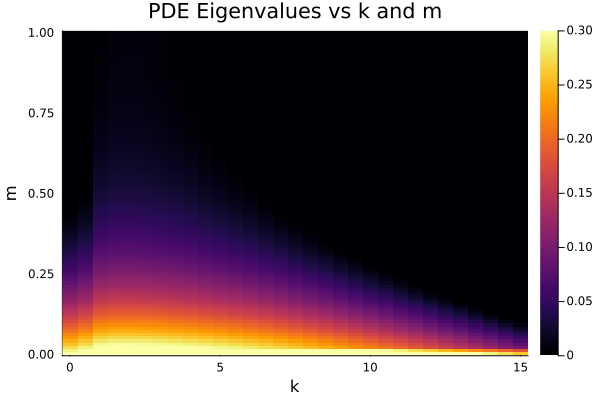

In [38]:
k_range = 0:0.5:15
m_range = 0:0.01:1
plot_eigenvalue_heatmap_3D(total_population, λ, ν, δ, g, m, d₁, d₂, d₃, m_range, k_range)